# Unemployment Analysis in India (with COVID-19 impact)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Load the data

In [2]:
df = pd.read_csv('Unemployment_in_India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-01-2019,Monthly,7.76,14055081,46.55,Rural
1,Andhra Pradesh,28-02-2019,Monthly,9.53,13856557,49.58,Rural
2,Andhra Pradesh,31-03-2019,Monthly,10.45,13725822,47.94,Rural
3,Andhra Pradesh,30-04-2019,Monthly,8.62,13891056,49.90,Rural
4,Andhra Pradesh,31-05-2019,Monthly,9.16,13864187,50.02,Rural


In [3]:
df.shape

(324, 7)

In [4]:
df.dtypes

Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object

In [5]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    8
Area                                       0
dtype: int64

There are a few missing values in the labour participation column, I'll just drop those rows since it's a small number.

In [6]:
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.dtypes

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

## Region-wise and month-wise trends

In [7]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg

Region
Bihar             15.747222
Chhattisgarh      14.477059
West Bengal       14.029412
Andhra Pradesh    12.813889
Maharashtra       12.045556
Karnataka         11.392222
Kerala            10.837778
Uttar Pradesh     10.646111
Tamil Nadu        10.362353
Jharkhand          9.348125
Gujarat            8.945556
Rajasthan          8.869375
Madhya Pradesh     8.634444
Delhi              8.389444
Haryana            8.064706
Odisha             8.009444
Punjab             7.969444
Assam              7.477778
Name: Estimated Unemployment Rate (%), dtype: float64

In [8]:
df['Month'] = df['Date'].dt.month
month_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
month_avg

Month
1      6.471429
2      7.053824
3      9.396857
4     17.947353
5     17.291143
6     15.978333
7      6.936667
8      6.568235
9      6.937778
10     6.707222
11     6.566111
12     6.419444
Name: Estimated Unemployment Rate (%), dtype: float64

Unemployment is clearly higher in some months than others, and it looks like it spikes a lot around April 2020, which lines up with the COVID lockdown period.

## Time series for a few major states

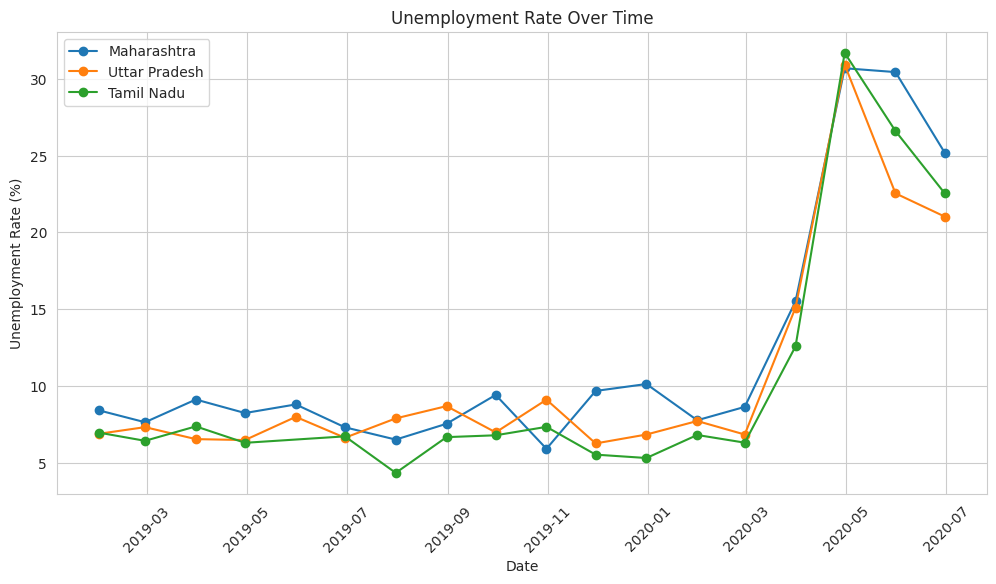

In [9]:
states = ['Maharashtra', 'Uttar Pradesh', 'Tamil Nadu']

plt.figure(figsize=(12,6))
for s in states:
    sub = df[df['Region'] == s].sort_values('Date')
    plt.plot(sub['Date'], sub['Estimated Unemployment Rate (%)'], marker='o', label=s)

plt.legend()
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

You can clearly see a big jump around April 2020 for all three states, then it starts coming back down a bit after that.

## Top 10 states by average unemployment rate

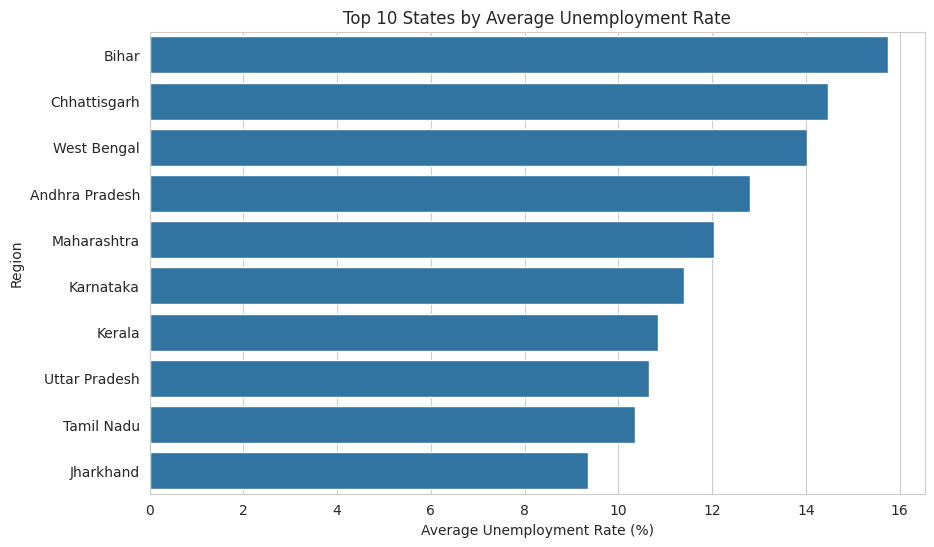

In [10]:
top10 = region_avg.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Top 10 States by Average Unemployment Rate')
plt.show()

## Correlation heatmap

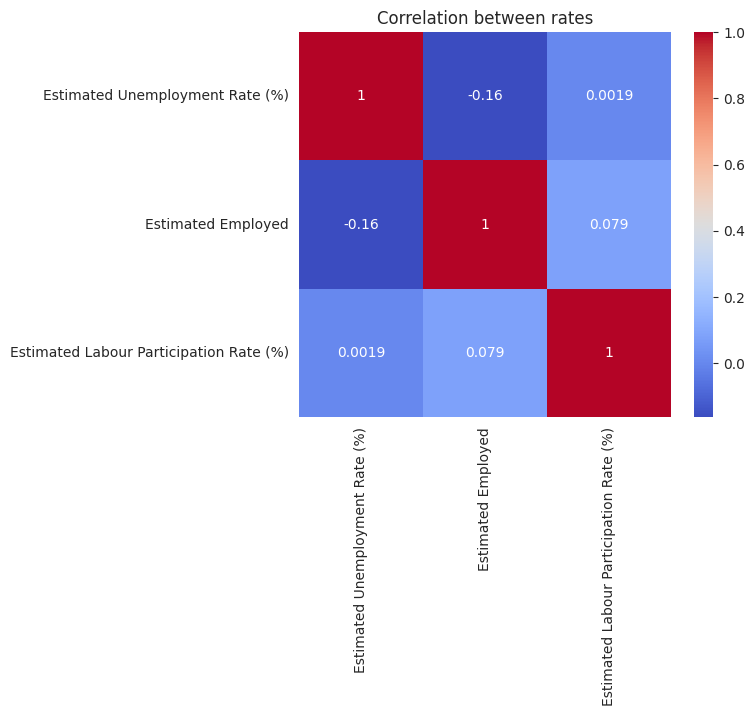

In [11]:
cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between rates')
plt.show()

Unemployment rate and number of employed people are negatively correlated, which makes sense - when unemployment goes up, fewer people are employed.

## Pre-COVID vs Post-COVID comparison

In [12]:
covid_cutoff = pd.Timestamp('2020-04-01')

pre_covid = df[df['Date'] < covid_cutoff]
post_covid = df[df['Date'] >= covid_cutoff]

print('Pre-COVID average unemployment rate:', pre_covid['Estimated Unemployment Rate (%)'].mean())
print('Post-COVID average unemployment rate:', post_covid['Estimated Unemployment Rate (%)'].mean())

Pre-COVID average unemployment rate: 7.074961832061069
Post-COVID average unemployment rate: 26.81611111111111


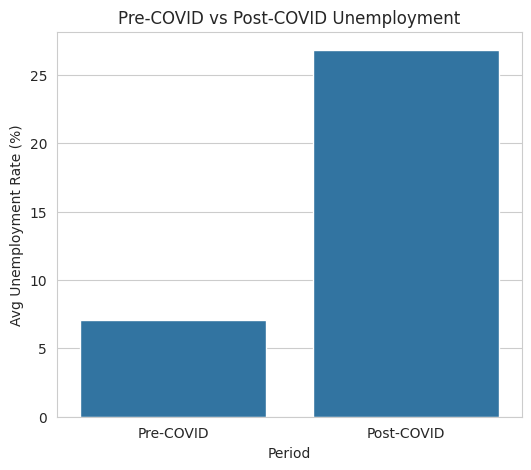

In [13]:
comparison = pd.DataFrame({
    'Period': ['Pre-COVID', 'Post-COVID'],
    'Avg Unemployment Rate (%)': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        post_covid['Estimated Unemployment Rate (%)'].mean()
    ]
})

plt.figure(figsize=(6,5))
sns.barplot(x='Period', y='Avg Unemployment Rate (%)', data=comparison)
plt.title('Pre-COVID vs Post-COVID Unemployment')
plt.show()

There's a huge jump in unemployment rate after COVID hit, which matches what happened in real life with the lockdown shutting down a lot of jobs suddenly.